# IMPORT LIBRARIES

In [51]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import randint as sp_randint

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

#from scikitplot.metrics import plot_roc

from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours


from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

from imblearn.combine import SMOTEENN
from imblearn.combine import SMOTETomek



In [5]:
#!pip install category_encoders

# LOAD CSV

In [6]:
pd.set_option('display.max_colwidth', None)  # Show full content in columns
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv("dataset/trai   n_post_outlier.csv")

# FAST CHECK AND PROCESS

In [8]:
cols_to_drop = ['Unnamed: 0', 'countryOfOrigin', 'genres', 'soundMixes', 'continent', 'filtered_genres', 'filtered_soundMixes']
df = df.drop(columns = cols_to_drop)

In [12]:
print(round((df['isAdult'].value_counts()*100)/df.shape[0]))

isAdult
0    98.0
1     2.0
Name: count, dtype: float64


# IMBALANCED LEARNING

In [13]:
target = 'isAdult'

attributes = [col for col in df.columns if col != target]

X = df[attributes].values
y = np.array(df[target]) 
X.shape, y.shape

((129663, 62), (129663,))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((103730, 62), (25933, 62), (103730,), (25933,))

## BASELINE MODELS

### DECISION TREE

In [15]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))


Migliori parametri trovati: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.90      0.88      0.89       493

    accuracy                           1.00     25933
   macro avg       0.95      0.94      0.94     25933
weighted avg       1.00      1.00      1.00     25933



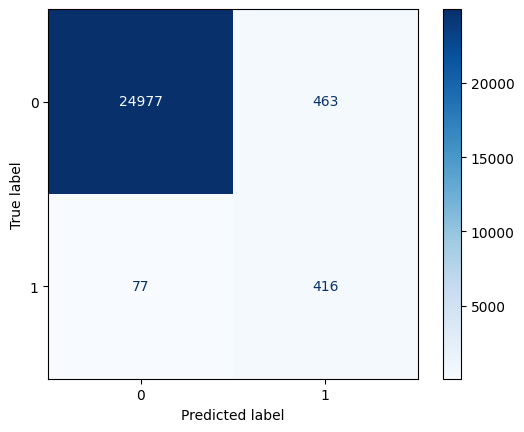

In [40]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')


### KNN

In [16]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_train, y_train) 

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

Migliori parametri trovati: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.80      0.78      0.79       493

    accuracy                           0.99     25933
   macro avg       0.90      0.89      0.89     25933
weighted avg       0.99      0.99      0.99     25933



## UNDERSAMPLING

### RANDOM

In [18]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 1973, np.int64(1): 1973})


In [19]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_randomunder = grid_search

Migliori parametri trovati: {'min_samples_split': 40, 'min_samples_leaf': 5, 'max_depth': 30, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     25440
           1       0.40      0.93      0.56       493

    accuracy                           0.97     25933
   macro avg       0.70      0.95      0.77     25933
weighted avg       0.99      0.97      0.98     25933



In [20]:
knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_randomunder = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     25440
           1       0.10      0.95      0.19       493

    accuracy                           0.84     25933
   macro avg       0.55      0.90      0.55     25933
weighted avg       0.98      0.84      0.90     25933



### TOMEK

In [21]:
tl = TomekLinks(sampling_strategy= 'majority')
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 101587, np.int64(1): 1973})


In [22]:
X_res.shape

(103560, 62)

In [23]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_tomek = grid_search

Migliori parametri trovati: {'min_samples_split': 30, 'min_samples_leaf': 10, 'max_depth': 30, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.92      0.86      0.89       493

    accuracy                           1.00     25933
   macro avg       0.96      0.93      0.94     25933
weighted avg       1.00      1.00      1.00     25933



In [24]:
knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_tomek = random_search

Migliori parametri trovati: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.78      0.79      0.79       493

    accuracy                           0.99     25933
   macro avg       0.89      0.89      0.89     25933
weighted avg       0.99      0.99      0.99     25933



### EDITED NEAREST NEIGHBOURS

In [25]:
enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 99635, np.int64(1): 1973})


In [ ]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_enn = grid_search

"""
Edited nearest neighbor
Migliori parametri trovati: {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_depth': 50, 'criterion': 'gini'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.86      0.90      0.88       493

    accuracy                           1.00     25933
   macro avg       0.93      0.95      0.94     25933
weighted avg       1.00      1.00      1.00     25933
"""

SyntaxError: incomplete input (3646562627.py, line 30)

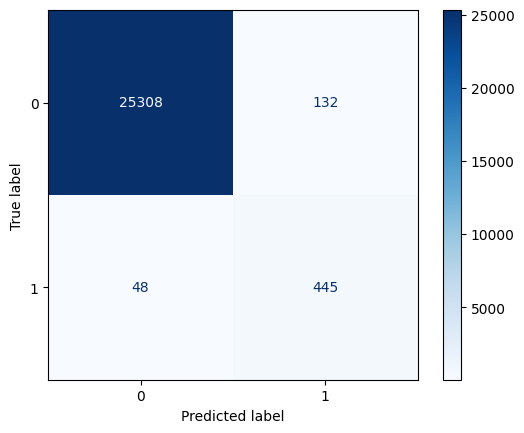

In [42]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')


In [27]:
knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_enn = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     25440
           1       0.57      0.82      0.67       493

    accuracy                           0.98     25933
   macro avg       0.78      0.90      0.83     25933
weighted avg       0.99      0.98      0.99     25933



## OVERSAMPLING

### Random 

In [28]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 101757, np.int64(1): 101757})


In [29]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_over = grid_search

Migliori parametri trovati: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.86      0.88      0.87       493

    accuracy                           1.00     25933
   macro avg       0.93      0.94      0.93     25933
weighted avg       1.00      1.00      1.00     25933



In [30]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_over = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     25440
           1       0.63      0.76      0.69       493

    accuracy                           0.99     25933
   macro avg       0.81      0.88      0.84     25933
weighted avg       0.99      0.99      0.99     25933



### Smote

In [31]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 101757, np.int64(1): 101757})


In [32]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_smote = grid_search

Migliori parametri trovati: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 30, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.87      0.88      0.87       493

    accuracy                           1.00     25933
   macro avg       0.93      0.94      0.94     25933
weighted avg       1.00      1.00      1.00     25933



In [33]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_smote = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     25440
           1       0.48      0.84      0.61       493

    accuracy                           0.98     25933
   macro avg       0.74      0.91      0.80     25933
weighted avg       0.99      0.98      0.98     25933



### Adasyn

In [34]:
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 101757, np.int64(1): 101641})


In [35]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_ada = grid_search

Migliori parametri trovati: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.83      0.87      0.85       493

    accuracy                           0.99     25933
   macro avg       0.91      0.94      0.92     25933
weighted avg       0.99      0.99      0.99     25933



In [36]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_ada = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     25440
           1       0.47      0.84      0.61       493

    accuracy                           0.98     25933
   macro avg       0.74      0.91      0.80     25933
weighted avg       0.99      0.98      0.98     25933



BEST ONE IS DECISION  TREE WITH ENN

Edited Nearest Neighbors (ENN) removes majority examples whose class disagrees with the majority of their k nearest neighbors (usually k=3).

This clears out noisy/ambiguous non‑adults near adult clusters, so your tree doesn’t over‑generalize and label everything in those neighborhoods as “adult.”

You keep nearly the full majority class, so you don’t pay the heavy precision price of random undersampling.

## MIX

### SMOTEENN

In [43]:
# 1. Inspect resampled distribution (optional)
smoteenn = SMOTEENN(random_state=42)
X_res, y_res = smoteenn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(1): 101747, np.int64(0): 97369})


In [49]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_smotenn = grid_search


Migliori parametri trovati: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 50, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     25440
           1       0.77      0.89      0.83       493

    accuracy                           0.99     25933
   macro avg       0.88      0.94      0.91     25933
weighted avg       0.99      0.99      0.99     25933



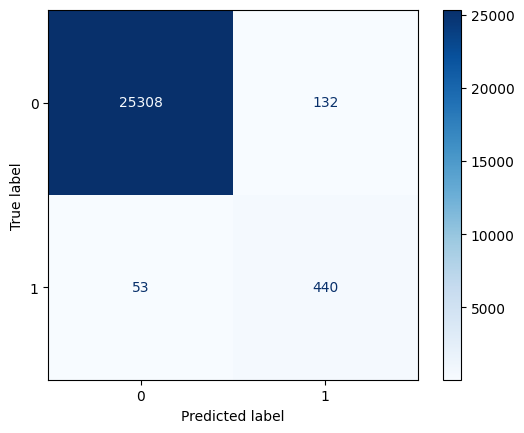

In [50]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')


### SMOTETomek

In [52]:
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 101755, np.int64(1): 101755})


In [53]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_smotenn = grid_search


Migliori parametri trovati: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25440
           1       0.84      0.88      0.86       493

    accuracy                           0.99     25933
   macro avg       0.92      0.94      0.93     25933
weighted avg       0.99      0.99      0.99     25933



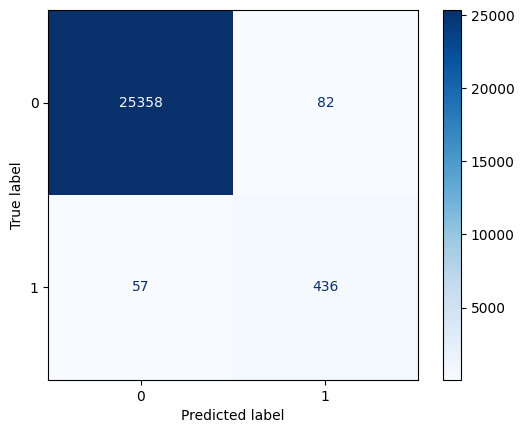

In [54]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')
